Creating subgroup of abstracts 

In [3]:
import functions

In [4]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_All", "txt")

In [3]:
#csv called corpus.csv saved to current working directory

In [5]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
print("There are a total of {} Abstracts".format(len(df)))
df.head()

There are a total of 27443 Abstracts


,name,text
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...


In [6]:
df["processed_text"] = df["text"].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...,"[eur, neurol, simultaneous, assessment, brain,..."
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...,"[ann, emerg, med, jan, sxhypoglycemia, abcs, s..."
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...,"[heart, jan, heartdiagnosis, carotid, sinus, h..."
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...,"[heart, jan, heartclinical, feature, adenosine..."
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...,"[anesth, analg, jan, prolong, coma, quadripleg..."


In [7]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]

df.head()

,name,text,processed_text,word_count
0,10601807.txt,1. Eur Neurol. 2000;43(1):39-46. doi: 10.1159/...,"[eur, neurol, simultaneous, assessment, brain,...",133
1,10613939.txt,1. Ann Emerg Med. 2000 Jan;35(1):43-6. doi: 10...,"[ann, emerg, med, jan, sxhypoglycemia, abcs, s...",164
2,10618329.txt,1. Heart. 2000 Jan;83(1):22-3. doi: 10.1136/he...,"[heart, jan, heartdiagnosis, carotid, sinus, h...",170
3,10618330.txt,1. Heart. 2000 Jan;83(1):24-8. doi: 10.1136/he...,"[heart, jan, heartclinical, feature, adenosine...",203
4,10624990.txt,1. Anesth Analg. 2000 Jan;90(1):116-8. doi: 10...,"[anesth, analg, jan, prolong, coma, quadripleg...",30


In [8]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count    26679.000000
mean       125.992354
std         88.379731
min          3.000000
25%         52.000000
50%        124.000000
75%        177.000000
max       2641.000000
Name: word_count, dtype: float64

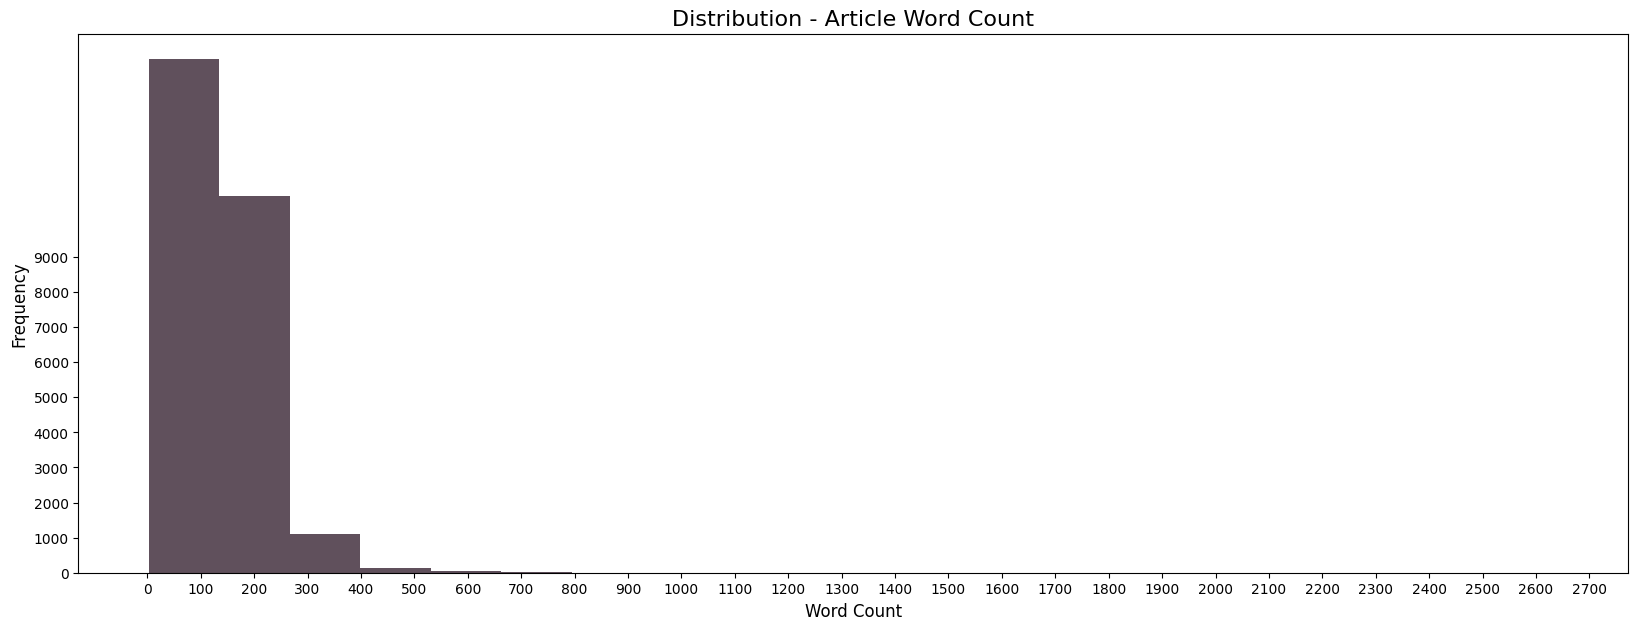

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 10000, 1000))
plt.xticks(np.arange(0, 2800, 100))

file_name = 'hist'

plt.show()

In [10]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flaten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,54084
1,university,37848
2,hospital,24912
3,index,22833
4,brain,20614
5,medicine,19578
6,medline,18759
7,medical,17909
8,study,17675
9,syncope,14771


C:\Users\noahj\AppData\Local\Temp\ipykernel_34364\1035846459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
C:\Users\noahj\AppData\Local\Temp\ipykernel_34364\1035846459.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


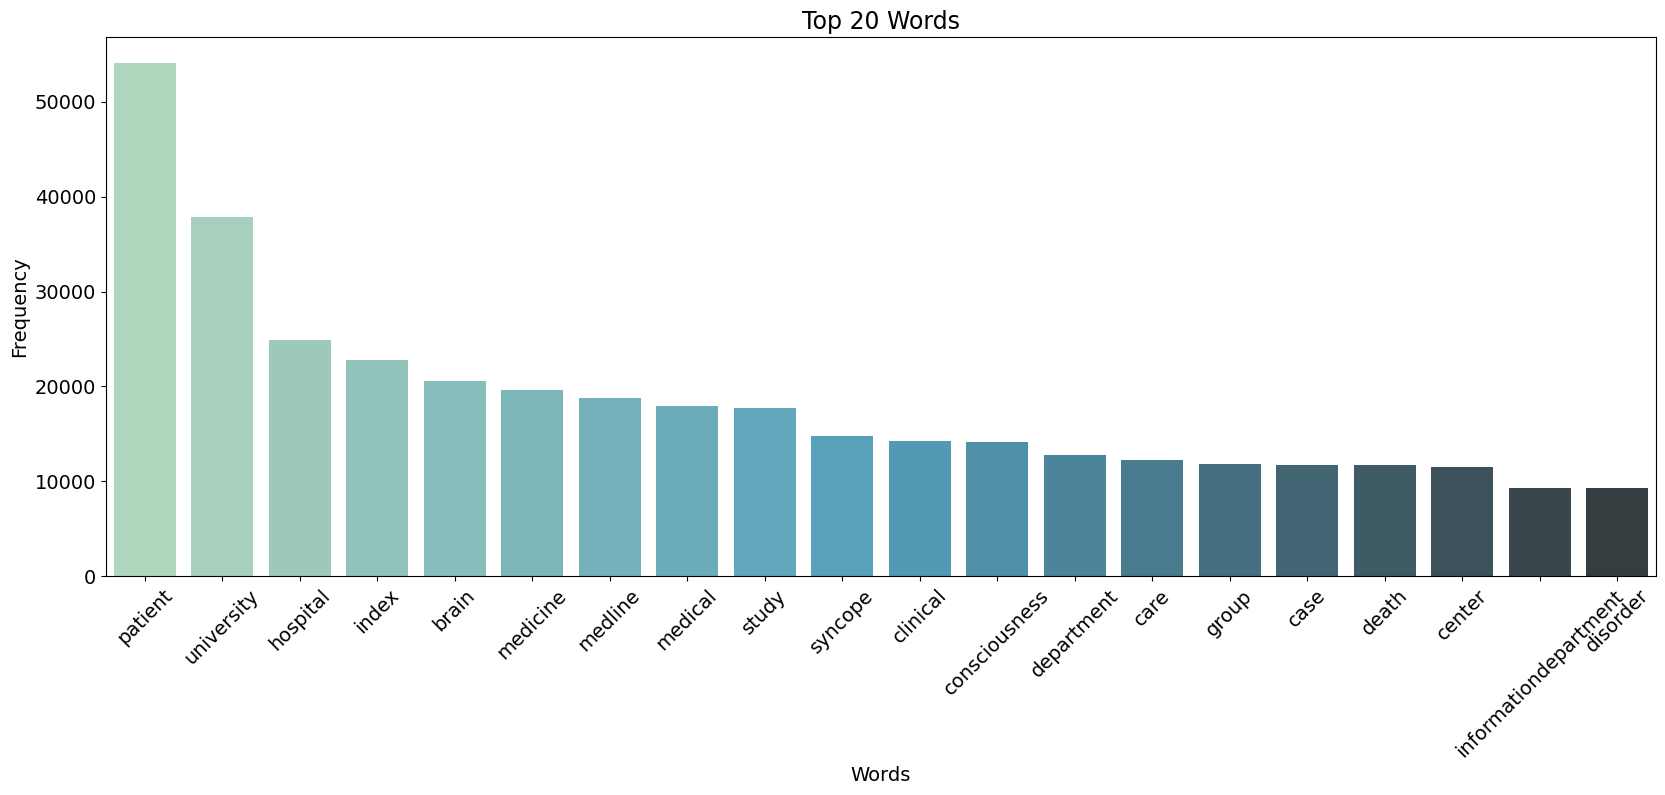

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot a bar chart for the top 20 most frequently occuring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=45,
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()

In [13]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

213327

In [14]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from operator import itemgetter

In [15]:
# Use sklearn's NMF to get the best num of topics via coherence score
texts = df['processed_text']

# Create a dictionary
# In sklearn a vectorizer is a mapping between words and their integer id
dictionary = CountVectorizer(
    analyzer=lambda x: x
)

# Filter out extremes to limit the number of features
dictionary.set_params(
    min_df = 3,
    max_df=0.85,
    #max_features=5000, removed so that we're not setting a limit for number of words
)

# Create the bag-of-words format
corpus = dictionary.fit_transform(texts)

# Create a list of the topic numbers we want to try
topic_nums = list(np.arange(5, 75 + 1, 5))

In [16]:
from itertools import combinations

# Calculate the coherence score for an sklearn NMF model
def get_coherence(model, corpus, topn=20):
    binary_corpus = (corpus > 0).astype(int)
    document_frequencies = np.asarray(binary_corpus.sum(axis=0)).ravel()
    num_documents = binary_corpus.shape[0]
    
    topic_scores = []

    for topic in model.components_:
        top_word_ids = topic.argsort()[-topn:]
        word_pair_scores = []

        for word_1, word_2 in combinations(top_word_ids, 2):
            co_occurrences = binary_corpus[:, word_1].multiply(
                binary_corpus[:, word_2]
            ).sum()

            if co_occurrences == 0:
                word_pair_scores.append(-1.0)
                continue

            if co_occurrences == num_documents:
                word_pair_scores.append(1.0)
                continue

            p_word_1 = document_frequencies[word_1] / num_documents
            p_word_2 = document_frequencies[word_2] / num_documents
            p_both = co_occurrences / num_documents

            score = np.log(
                p_both / (p_word_1 * p_word_2)
            ) / -np.log(p_both)

            word_pair_scores.append(score)

        topic_scores.append(np.mean(word_pair_scores))

    return np.mean(topic_scores)

c:\Users\noahj\Desktop\Prof Phan Research\2026 Project\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


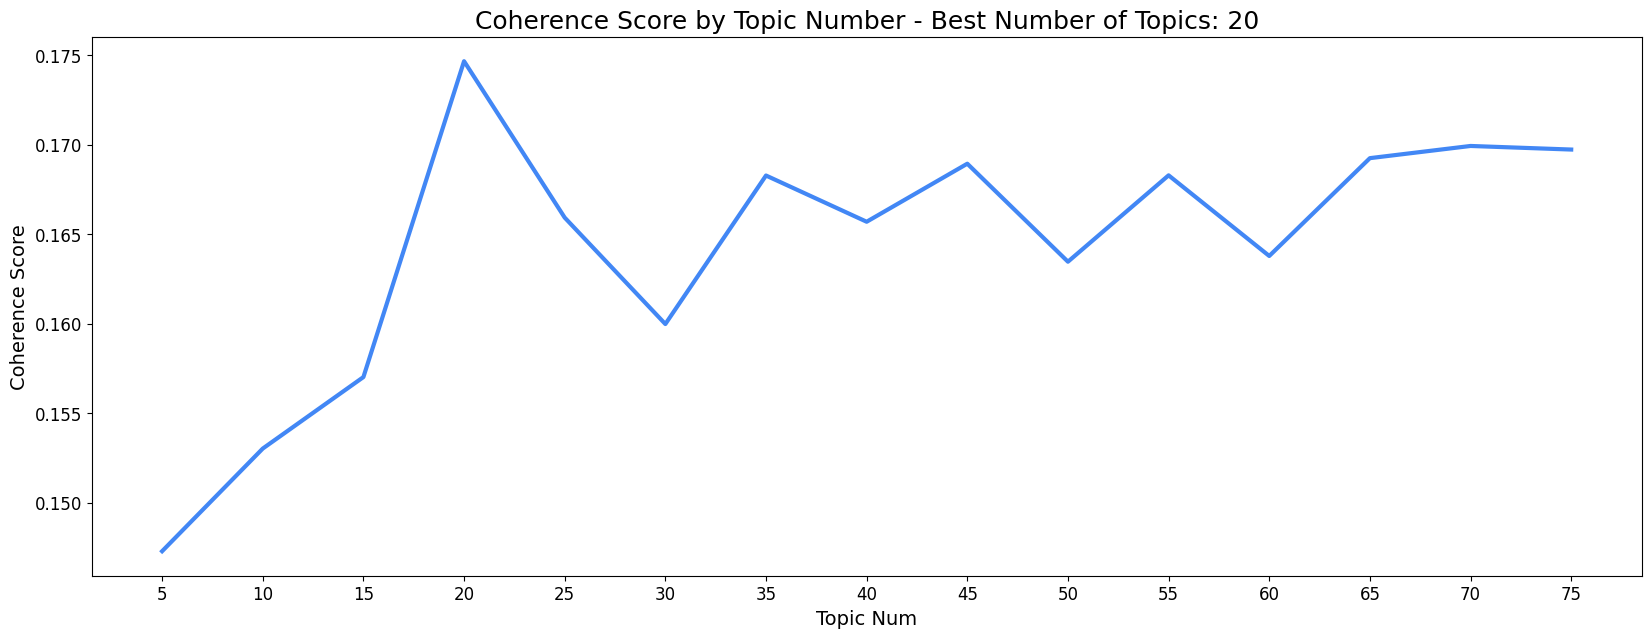

In [17]:
# Run the nmf model and calculate the coherence score
# for each number of topics
coherence_scores = []

for num in topic_nums:
    nmf = NMF(
        n_components=num,
        max_iter=300,
        tol=0.0001,
        random_state=42
    )
    
    nmf.fit(corpus)
    
    # Run the coherence model to get the score
    cm = get_coherence(
        model=nmf,
        corpus=corpus
    )
    
    coherence_scores.append(round(cm, 5))

# Get the number of topics with the highest coherence score
scores = list(zip(topic_nums, coherence_scores))
best_num_topics = sorted(scores, key=itemgetter(1), reverse=True)[0][0]

# Plot the results
fig = plt.figure(figsize=(20, 7))

plt.plot(
    topic_nums,
    coherence_scores,
    linewidth=3,
    color='#4287f5'
)

plt.xlabel("Topic Num", fontsize=14)
plt.ylabel("Coherence Score", fontsize=14)
plt.title('Coherence Score by Topic Number - Best Number of Topics: {}'.format(best_num_topics), fontsize=18)
plt.xticks(np.arange(5, max(topic_nums) + 1, 5), fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [18]:
# Now use the number of topics with the 
# highest coherence score to run the 
# sklearn nmf model

texts = df['processed_text']

# Create the tfidf weights
tfidf_vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.85,
    #max_features=5000,
    ngram_range=(1, 2),
    preprocessor=' '.join
)

tfidf = tfidf_vectorizer.fit_transform(texts)

# Save the feature names for later to create topic summaries
tfidf_fn = tfidf_vectorizer.get_feature_names_out()

# Run the nmf model
nmf = NMF(
    n_components=best_num_topics,
    init='nndsvd',
    max_iter=500,
    l1_ratio=0.0,
    solver='cd',
    tol=1e-4,
    random_state=42
).fit(tfidf)

In [19]:
from nltk.tokenize import TweetTokenizer, RegexpTokenizer

def topic_table(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        t = (topic_idx)
        topics[t] = [feature_names[i] for i in top_words(topic, n_top_words)]
    return pd.DataFrame(topics)

def top_words(topic, n_top_words):
    return topic.argsort()[:-n_top_words - 1:-1]  

def whitespace_tokenizer(text): 
    pattern = r"(?u)\b\w\w+\b" 
    tokenizer_regex = RegexpTokenizer(pattern)
    tokens = tokenizer_regex.tokenize(text)
    return tokens

# Funtion to remove duplicate words
def unique_words(text): 
    ulist = []
    [ulist.append(x) for x in text if x not in ulist]
    return ulist

In [20]:
# Use the top words for each cluster by tfidf weight
# to create 'topics'

# Getting a df with each topic by document
docweights = nmf.transform(tfidf_vectorizer.transform(texts))

n_top_words = 8

topic_df = topic_table(
    nmf,
    tfidf_fn,
    n_top_words
).T

# Cleaning up the top words to create topic summaries
topic_df['topics'] = topic_df.apply(lambda x: [' '.join(x)], axis=1) # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets
topic_df['topics'] = topic_df['topics'].apply(lambda x: whitespace_tokenizer(x)) # tokenize
topic_df['topics'] = topic_df['topics'].apply(lambda x: unique_words(x))  # Removing duplicate words
topic_df['topics'] = topic_df['topics'].apply(lambda x: [' '.join(x)])  # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets

topic_df.head(best_num_topics) #This depends on output

,0,1,2,3,4,5,6,7,topics
0,consciousness,state,conscious,disorder,doc,mcs,patient,brain,consciousness state conscious disorder doc mcs...
1,donor,dcd,graft,transplant,transplantation,liver,kidney,recipient,donor dcd graft transplant transplantation liv...
2,syncope,patient,ventricular,cardiac,cardiology,heart,ecg,episode,syncope patient ventricular cardiac cardiology...
3,medicine,university,department,school,school medicine,emergency,center,medical,medicine university department school emergenc...
4,death,brain death,brain,determination,criterion,diagnosis brain,dead,diagnosis,death brain determination criterion diagnosis ...
5,patient,group,outcome,score,study,coma,stroke,year,patient group outcome score study coma stroke ...
6,case,report,present,yearold,symptom,syndrome,cause,treatment,case report present yearold symptom syndrome c...
7,medline,index medline,index,spmid index,spmid,lancet,epub,clin,medline index spmid lancet epub clin
8,organ,donation,donor,organ donation,family,organ donor,transplant,procurement,organ donation donor family transplant procure...
9,cardiac,arrest,cardiac arrest,copenhagen,hypothermia,outcome,comatose,university hospital,cardiac arrest copenhagen hypothermia outcome ...


In [21]:
# Create a df with only the created topics and topic num
topic_df = topic_df['topics'].reset_index()
topic_df.columns = ['topic_num', 'topics']

topic_df

,topic_num,topics
0,0,consciousness state conscious disorder doc mcs...
1,1,donor dcd graft transplant transplantation liv...
2,2,syncope patient ventricular cardiac cardiology...
3,3,medicine university department school emergenc...
4,4,death brain determination criterion diagnosis ...
5,5,patient group outcome score study coma stroke ...
6,6,case report present yearold symptom syndrome c...
7,7,medline index spmid lancet epub clin
8,8,organ donation donor family transplant procure...
9,9,cardiac arrest copenhagen hypothermia outcome ...


In [22]:
# Creating a temp df with the url and topic num to join on
name = df['name'].tolist()

df_temp = pd.DataFrame({
    'name': name,
    'topic_num': docweights.argmax(axis=1)
})

# Merging to get the topic num with url
merged_topic = df_temp.merge(
    topic_df,
    on='topic_num',
    how='left'
)

# Merging with the original df
df_topics = pd.merge(
    df,
    merged_topic,
    on='name',
    how='left'
)

df_topics = df_topics.drop(
    'text',
    axis=1
)

df_topics.head(10)

,name,processed_text,word_count,topic_num,topics
0,10601807.txt,"[eur, neurol, simultaneous, assessment, brain,...",133,10,tilt test blood vasovagal pressure group headu...
1,10613939.txt,"[ann, emerg, med, jan, sxhypoglycemia, abcs, s...",164,19,child pediatric pediatr children childrens hos...
2,10618329.txt,"[heart, jan, heartdiagnosis, carotid, sinus, h...",170,10,tilt test blood vasovagal pressure group headu...
3,10618330.txt,"[heart, jan, heartclinical, feature, adenosine...",203,10,tilt test blood vasovagal pressure group headu...
4,10624990.txt,"[anesth, analg, jan, prolong, coma, quadripleg...",30,18,bioeth pmid index sep winter jun
5,10631230.txt,"[chest, jan, chestcocaineinduce, bradyarrhythm...",63,17,new york medical center university
6,10634522.txt,"[clin, nucl, med, jan, tcm, hexamethylpropylen...",208,4,death brain determination criterion diagnosis ...
7,10636153.txt,"[neurology, jan, wnlspontaneous, reflex, movem...",65,14,neurology mayo wnlpmid index clinic rochester ...
8,10636154.txt,"[neurology, jan, wnldecerebratelike, posture, ...",74,14,neurology mayo wnlpmid index clinic rochester ...
9,10636279.txt,"[coll, cardiol, jan, sfalse, positive, headup,...",200,10,tilt test blood vasovagal pressure group headu...


In [23]:
# Showing the 3 matrices we get witn nmf
A = tfidf_vectorizer.transform(texts)
W = nmf.components_
H = nmf.transform(A)

print('A = {} x {}'.format(A.shape[0], A.shape[1])) #Document x Term
print('W = {} x {}'.format(W.shape[0], W.shape[1])) #Topic x Term
print('H = {} x {}'.format(H.shape[0], H.shape[1])) # Document x Topic

A = 26679 x 192556
W = 20 x 192556
H = 26679 x 20


In [24]:
#Save it
df_topics.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_Abstracts\H_DocumentTopicMatrix.csv")
topic_df.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_Abstracts\TopicList.csv")

Topics 0 and 16.

In [25]:
#remove empty "processed_text" strings that are non-english
print("Initial number of papers: {}".format(len(df)))

df_relevant = df_topics[(df_topics.topics == "consciousness state conscious disorder doc mcs patient brain")]
df_relevant = pd.concat([df_relevant, df_topics[(df_topics.topics == "injury tbi brain traumatic head severe")]])

print("Irrelevant papers removed: {}".format(len(df) - len(df_relevant)))
print("Papers Remaining: {}".format(len(df_relevant)))
df_relevant

Initial number of papers: 26679
Irrelevant papers removed: 23973
Papers Remaining: 2706


,name,processed_text,word_count,topic_num,topics
17,10648442.txt,"[brain, feb, brainelectrophysiological, eviden...",158,0,consciousness state conscious disorder doc mcs...
206,10816841.txt,"[int, psychoanal, feb, unconscious, psychosis,...",121,0,consciousness state conscious disorder doc mcs...
222,10832265.txt,"[minerva, anestesiol, aprvegetative, state, pr...",130,0,consciousness state conscious disorder doc mcs...
327,10908189.txt,"[brain, aug, brainauditory, process, vegetativ...",149,0,consciousness state conscious disorder doc mcs...
346,10924237.txt,"[conscious, cogn, jun, discussion, ccogthe, un...",125,0,consciousness state conscious disorder doc mcs...
...,...,...,...,...,...
26476,41269098.txt,"[neurotrauma, nov, online, ahead, printhistory...",313,16,injury tbi brain traumatic head severe
26561,41439785.txt,"[inj, violence, dec, online, ahead, printevalu...",220,16,injury tbi brain traumatic head severe
26650,41651098.txt,"[neuroimage, mar, jneuroimage, epub, feb, unve...",280,16,injury tbi brain traumatic head severe
26654,41661561.txt,"[psychol, trauma, feb, tra, online, ahead, pri...",142,16,injury tbi brain traumatic head severe


In [26]:
df_relevant.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_Abstracts\H_RelevantDocumentTopicMatrix.csv")

In [27]:
print("{} number of abstracts in topic 0".format(df_relevant[df_relevant.topic_num == 0].shape[0]))

1626 number of abstracts in topic 0


In [28]:
print("{} number of abstracts in topic 16".format(df_relevant[df_relevant.topic_num == 16].shape[0]))

1080 number of abstracts in topic 16


In [29]:
df_relevant['word_count'].describe()

count    2706.000000
mean      163.349593
std        70.052564
min         8.000000
25%       120.000000
50%       159.000000
75%       200.750000
max       927.000000
Name: word_count, dtype: float64

## 2.2 Create a subgroup from the Full Texts corpus using NMF

In [30]:
import functions

In [31]:
functions.outputs.make_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\valid_pdfs", "txt")

In [30]:
#csv called corpus.csv saved to current working directory

In [32]:
import pandas as pd
import csv

df=pd.read_csv('corpus.csv', encoding = 'unicode_escape', encoding_errors = 'ignore', engine ='c')
print("There are a total of {} Full Texts".format(len(df)))
df.head()

There are a total of 3856 Full Texts


,name,text
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
2,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
3,10663916.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
4,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...


In [33]:
df["processed_text"] = df["text"].apply(functions.processing.preprocess)
df.head()

,name,text,processed_text
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncongenital, acth, deficiency, rar..."
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncryptococcus, neoformans, bud, no..."
2,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, january, accept, july, barnes, robso..."
3,10663916.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,[]
4,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[qxdreceive, june, abstract, objective, studyw..."


In [34]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x))
#add in a line to remove 0 wc texts
df = df[~(df.word_count == 0)]

df.head()

,name,text,processed_text,word_count
0,10663290.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncongenital, acth, deficiency, rar...",1002
1,10663466.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[introductioncryptococcus, neoformans, bud, no...",536
2,10663515.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[receive, january, accept, july, barnes, robso...",2275
4,10672428.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[qxdreceive, june, abstract, objective, studyw...",1255
5,10674845.txt,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...,"[case, report, dright, ventricular, cardiomyop...",1105


In [35]:
# Descriptive statistics for word count
df['word_count'].describe()
#95%CI Calculated: 

count     3609.000000
mean      2307.542533
std       1867.298201
min         13.000000
25%       1069.000000
50%       2055.000000
75%       3171.000000
max      64826.000000
Name: word_count, dtype: float64

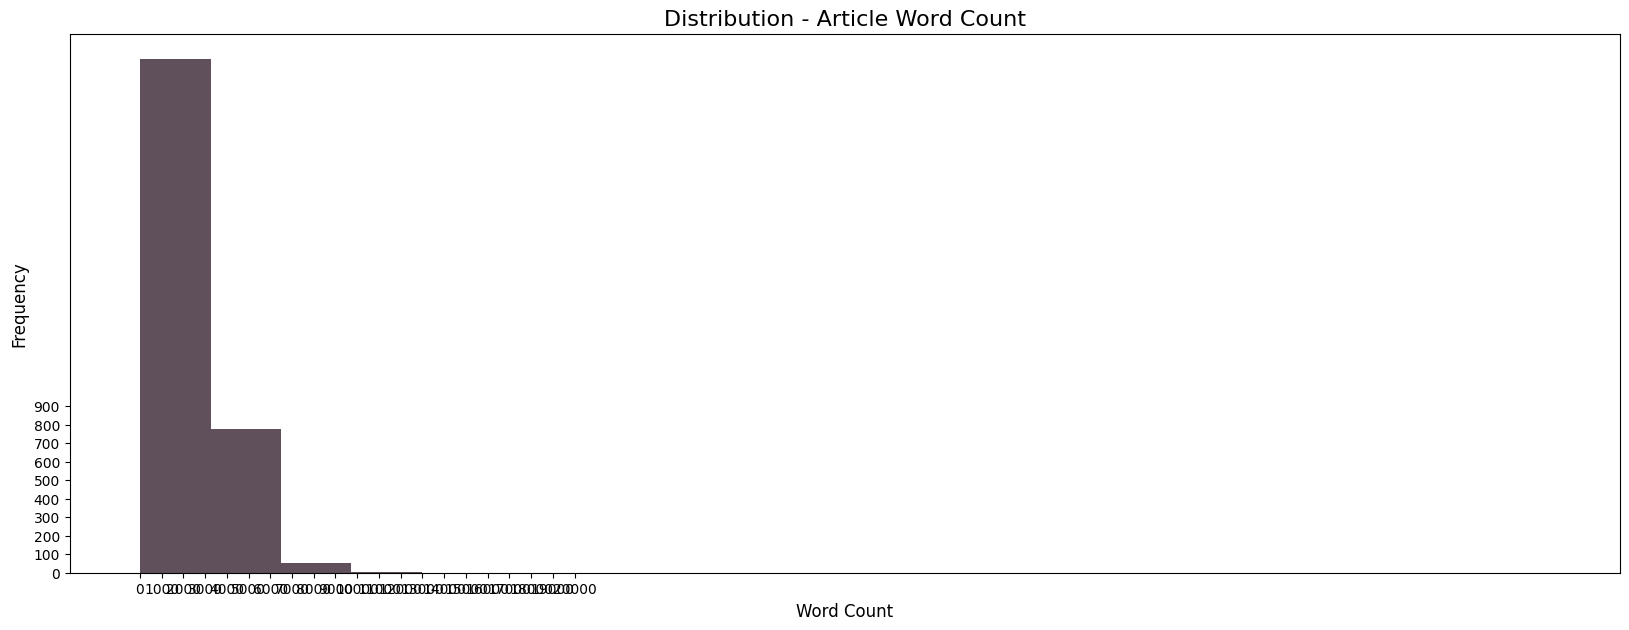

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a hist of the word counts
fig = plt.figure(figsize=(20,7))

plt.hist(
    df['word_count'],
    bins=20,
    color='#60505C'
)

plt.title('Distribution - Article Word Count', fontsize=16)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Word Count', fontsize=12)
plt.yticks(np.arange(0, 1000, 100))
plt.xticks(np.arange(0, 21000, 1000))

file_name = 'hist'

plt.show()

In [37]:
from collections import Counter

# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# Flaten the list of lists
p_text = [item for sublist in p_text for item in sublist]

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(20),
    columns=['word', 'frequency']
)

top_20

,word,frequency
0,patient,120439
1,study,57309
2,brain,48066
3,group,30105
4,consciousness,26890
5,clinical,25549
6,death,23657
7,result,22180
8,time,22144
9,show,21450


C:\Users\noahj\AppData\Local\Temp\ipykernel_34364\1035846459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
C:\Users\noahj\AppData\Local\Temp\ipykernel_34364\1035846459.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


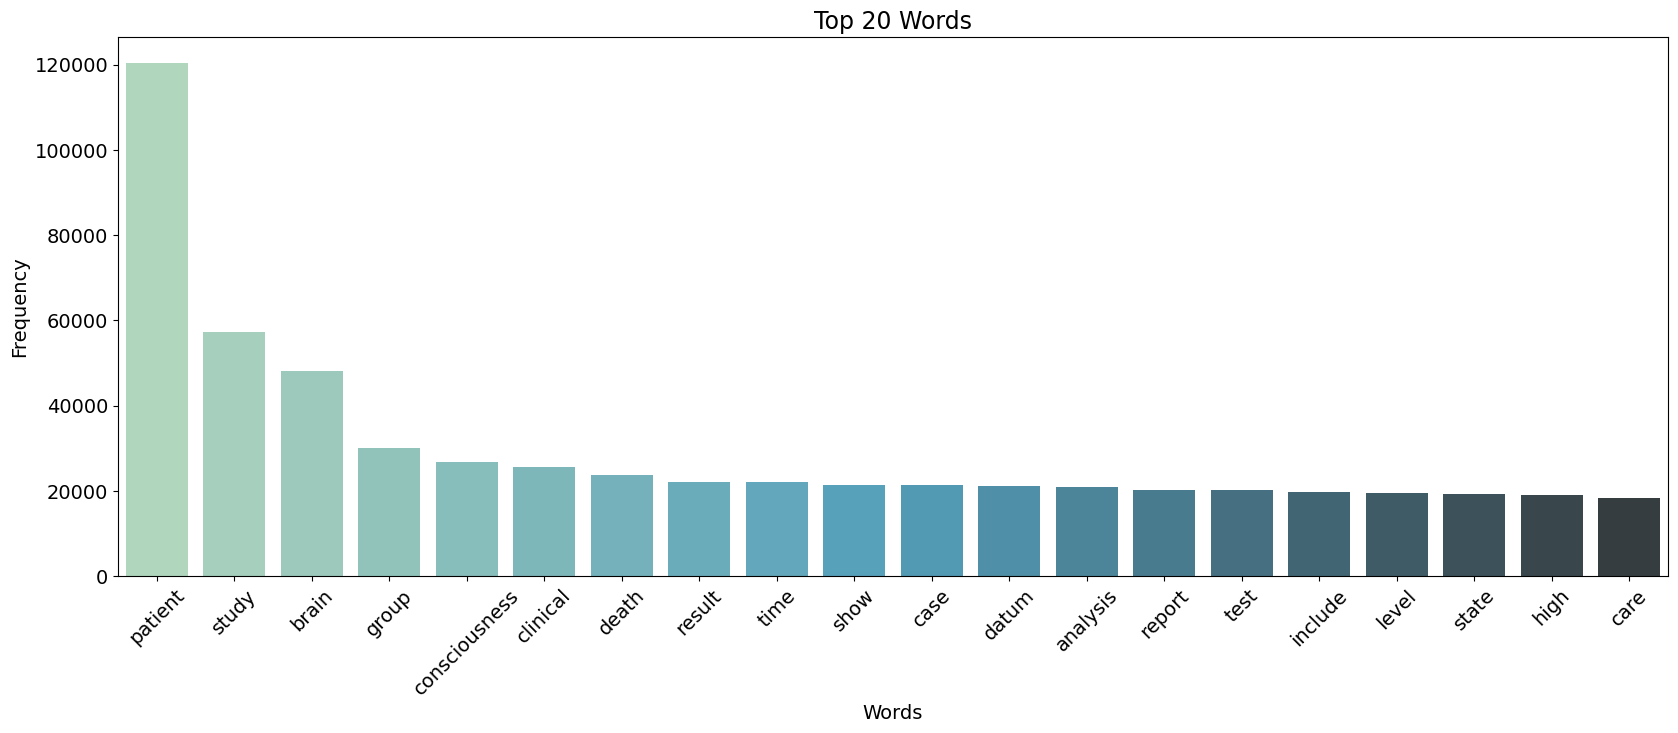

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot a bar chart for the top 20 most frequently occuring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=45,
    fontsize=14
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()

In [39]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

704501

In [40]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from operator import itemgetter

In [41]:
# Use sklearn's NMF to get the best num of topics via coherence score
texts = df['processed_text']

# Create a dictionary
# In sklearn a vectorizer is a mapping between words and their integer id
dictionary = CountVectorizer(
    analyzer=lambda x: x
)

# Filter out extremes to limit the number of features
dictionary.set_params(
    min_df = 3,
    max_df=0.85,
    #max_features=5000, removed so that we're not setting a limit for number of words
)

# Create the bag-of-words format
corpus = dictionary.fit_transform(texts)

# Create a list of the topic numbers we want to try
topic_nums = list(np.arange(5, 75 + 1, 5))

c:\Users\noahj\Desktop\Prof Phan Research\2026 Project\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\noahj\Desktop\Prof Phan Research\2026 Project\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\noahj\Desktop\Prof Phan Research\2026 Project\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


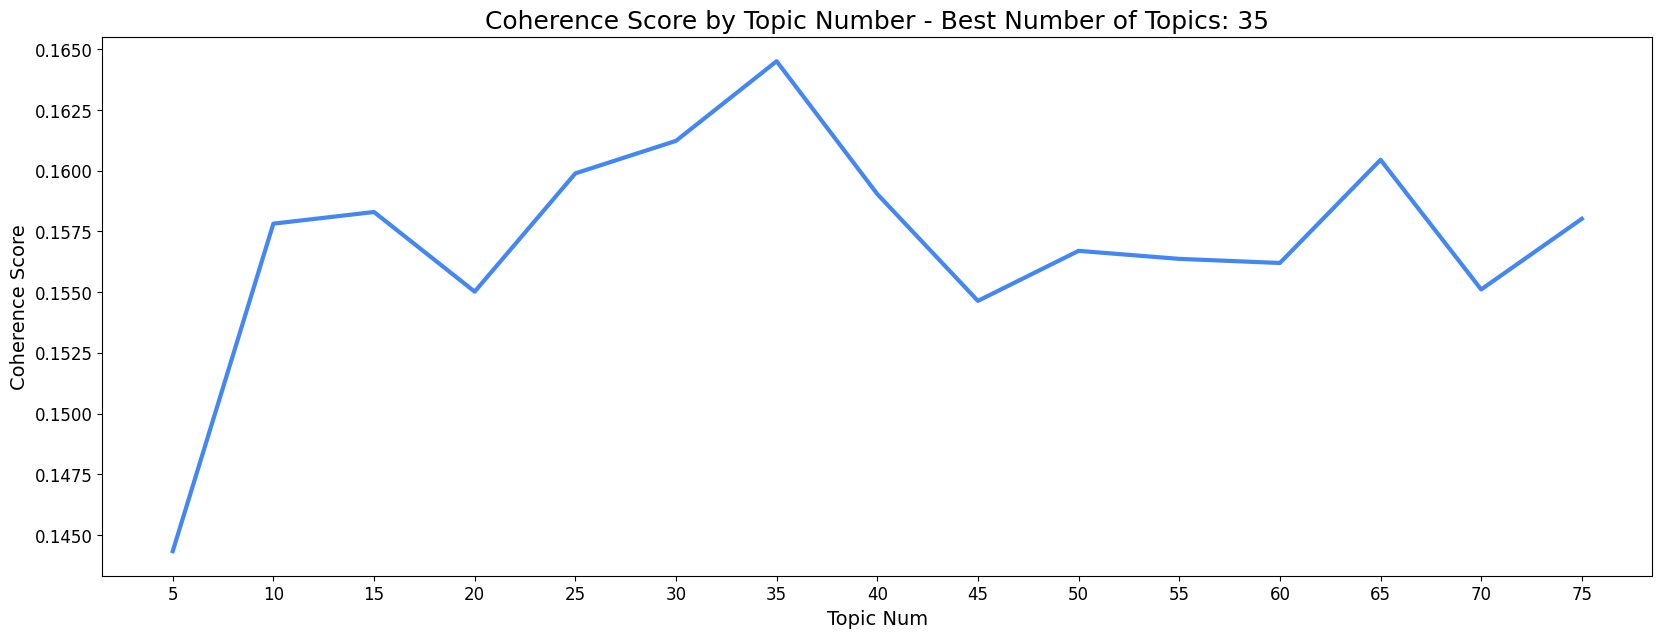

In [42]:
# Run the nmf model and calculate the coherence score
# for each number of topics
coherence_scores = []

for num in topic_nums:
    nmf = NMF(
        n_components=num,
        max_iter=300,
        tol=0.0001,
        random_state=42
    )

    nmf.fit(corpus)

    # Run the coherence model to get the score
    cm = get_coherence(
        model=nmf,
        corpus=corpus
    )

    coherence_scores.append(round(cm, 5))

# Get the number of topics with the highest coherence score
scores = list(zip(topic_nums, coherence_scores))
best_num_topics = sorted(scores, key=itemgetter(1), reverse=True)[0][0]

# Plot the results
fig = plt.figure(figsize=(20, 7))

plt.plot(
    topic_nums,
    coherence_scores,
    linewidth=3,
    color='#4287f5'
)

plt.xlabel("Topic Num", fontsize=14)
plt.ylabel("Coherence Score", fontsize=14)
plt.title('Coherence Score by Topic Number - Best Number of Topics: {}'.format(best_num_topics), fontsize=18)
plt.xticks(np.arange(5, max(topic_nums) + 1, 5), fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [43]:
# Now use the number of topics with the
# highest coherence score to run the
# sklearn nmf model

texts = df['processed_text']

# Create the tfidf weights
tfidf_vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.85,
    #max_features=5000,
    ngram_range=(1, 2),
    preprocessor=' '.join
)

tfidf = tfidf_vectorizer.fit_transform(texts)

# Save the feature names for later to create topic summaries
tfidf_fn = tfidf_vectorizer.get_feature_names_out()

# Run the nmf model
nmf = NMF(
    n_components=best_num_topics,
    init='nndsvd',
    max_iter=500,
    l1_ratio=0.0,
    solver='cd',
    tol=1e-4,
    random_state=42
).fit(tfidf)

In [44]:
from nltk.tokenize import TweetTokenizer, RegexpTokenizer

def topic_table(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        t = (topic_idx)
        topics[t] = [feature_names[i] for i in top_words(topic, n_top_words)]
    return pd.DataFrame(topics)

def top_words(topic, n_top_words):
    return topic.argsort()[:-n_top_words - 1:-1]

def whitespace_tokenizer(text):
    pattern = r"(?u)\b\w\w+\b"
    tokenizer_regex = RegexpTokenizer(pattern)
    tokens = tokenizer_regex.tokenize(text)
    return tokens

# Funtion to remove duplicate words
def unique_words(text):
    ulist = []
    [ulist.append(x) for x in text if x not in ulist]
    return ulist

In [45]:
# Use the top words for each cluster by tfidf weight
# to create 'topics'

# Getting a df with each topic by document
docweights = nmf.transform(tfidf_vectorizer.transform(texts))

n_top_words = 8

topic_df = topic_table(
    nmf,
    tfidf_fn,
    n_top_words
).T

# Cleaning up the top words to create topic summaries
topic_df['topics'] = topic_df.apply(lambda x: [' '.join(x)], axis=1) # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets
topic_df['topics'] = topic_df['topics'].apply(lambda x: whitespace_tokenizer(x)) # tokenize
topic_df['topics'] = topic_df['topics'].apply(lambda x: unique_words(x))  # Removing duplicate words
topic_df['topics'] = topic_df['topics'].apply(lambda x: [' '.join(x)])  # Joining each word into a list
topic_df['topics'] = topic_df['topics'].str[0]  # Removing the list brackets

topic_df.head(best_num_topics) #This depends on output

,0,1,2,3,4,5,6,7,topics
0,mcs,crsr,doc,uws,consciousness,vsuws,disorder consciousness,vegetative,mcs crsr doc uws consciousness vsuws disorder ...
1,syncope,episode,vasovagal,syncopal,cardiac,history,patient syncope,vasovagal syncope,syncope episode vasovagal syncopal cardiac his...
2,death,brain death,brain,determination,dead,organ,criterion,determination death,death brain determination dead organ criterion
3,mri,lesion,dwi,matter,imaging,image,adc,white matter,mri lesion dwi matter imaging image adc white
4,donor,graft,dcd,transplantation,dbd,kidney,transplant,recipient,donor graft dcd transplantation dbd kidney tra...
5,arrest,cardiac arrest,cardiac,outcome,hypothermia,nse,resuscitation,ssep,arrest cardiac outcome hypothermia nse resusci...
6,care,family,decision,life,state,treatment,court,medical,care family decision life state treatment cour...
7,tilt,hut,orthostatic,pressure,blood,headup,blood pressure,supine,tilt hut orthostatic pressure blood headup supine
8,ventricular,ecg,cardiac,coronary,heart,cardiomyopathy,pulmonary,block,ventricular ecg cardiac coronary heart cardiom...
9,encephalitis,csf,antinmdar,antibody,antibodie,antinmdar encephalitis,autoimmune,receptor,encephalitis csf antinmdar antibody antibodie ...


In [46]:
# Create a df with only the created topics and topic num
topic_df = topic_df['topics'].reset_index()
topic_df.columns = ['topic_num', 'topics']

topic_df

,topic_num,topics
0,0,mcs crsr doc uws consciousness vsuws disorder ...
1,1,syncope episode vasovagal syncopal cardiac his...
2,2,death brain determination dead organ criterion
3,3,mri lesion dwi matter imaging image adc white
4,4,donor graft dcd transplantation dbd kidney tra...
5,5,arrest cardiac outcome hypothermia nse resusci...
6,6,care family decision life state treatment cour...
7,7,tilt hut orthostatic pressure blood headup supine
8,8,ventricular ecg cardiac coronary heart cardiom...
9,9,encephalitis csf antinmdar antibody antibodie ...


In [47]:
# Creating a temp df with the url and topic num to join on
name = df['name'].tolist()

df_temp = pd.DataFrame({
    'name': name,
    'topic_num': docweights.argmax(axis=1)
})

# Merging to get the topic num with url
merged_topic = df_temp.merge(
    topic_df,
    on='topic_num',
    how='left'
)

# Merging with the original df
df_topics = pd.merge(
    df,
    merged_topic,
    on='name',
    how='left'
)

df_topics = df_topics.drop(
    'text',
    axis=1
)

df_topics.head(10)

,name,processed_text,word_count,topic_num,topics
0,10663290.txt,"[introductioncongenital, acth, deficiency, rar...",1002,32,mgdl serum case blood level day hypoglycemia coma
1,10663466.txt,"[introductioncryptococcus, neoformans, bud, no...",536,3,mri lesion dwi matter imaging image adc white
2,10663515.txt,"[receive, january, accept, july, barnes, robso...",2275,20,injury tbi brain traumatic outcome etal
3,10672428.txt,"[qxdreceive, june, abstract, objective, studyw...",1255,22,child malaria pediatric severe falciparum cere...
4,10674845.txt,"[case, report, dright, ventricular, cardiomyop...",1105,8,ventricular ecg cardiac coronary heart cardiom...
5,10730735.txt,"[pdfcan, anesth, purpose, proper, care, trauma...",1111,34,bis propofol anesthesia value remimazolam loc ...
6,10751119.txt,"[umbgarciaqxdcarlos, garciajos, ferroeuropean,...",164,2,death brain determination dead organ criterion
7,10758692.txt,"[cdi, volume, issue, adverse, event, follow, i...",2195,22,child malaria pediatric severe falciparum cere...
8,10774959.txt,"[transient, nature, interference, effect, hete...",2239,32,mgdl serum case blood level day hypoglycemia coma
9,10784303.txt,"[introductioncorneal, exposure, microbial, ker...",1464,33,aberration corneal hoas eye astigmatism trefoi...


In [48]:
# Showing the 3 matrices we get witn nmf
A = tfidf_vectorizer.transform(texts)
W = nmf.components_
H = nmf.transform(A)

print('A = {} x {}'.format(A.shape[0], A.shape[1])) #Document x Term
print('W = {} x {}'.format(W.shape[0], W.shape[1])) #Topic x Term
print('H = {} x {}'.format(H.shape[0], H.shape[1])) # Document x Topic

A = 3609 x 414429
W = 35 x 414429
H = 3609 x 35


In [49]:
#Save it
df_topics.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_FullTexts\H_DocumentTopicMatrix.csv")
topic_df.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_FullTexts\TopicList.csv")

In [50]:
#remove empty "processed_text" strings that are non-english
print("Initial number of papers: {}".format(len(df)))

#remove all texts that don't align with relevant topics
df_relevant = df_topics[(df_topics.topics == "mcs crsr doc uws consciousness vsuws disorder vegetative")]
df_relevant = pd.concat([df_relevant, df_topics[(df_topics.topics == "injury tbi brain traumatic outcome etal")]])
df_relevant = pd.concat([df_relevant, df_topics[(df_topics.topics == "connectivity network brain functional consciousness region state")]])
df_relevant = pd.concat([df_relevant, df_topics[(df_topics.topics == "score gcs scale coma glasgow outcome")]])

print("Irrelevant papers removed: {}".format(len(df) - len(df_relevant)))
print("Papers Remaining: {}".format(len(df_relevant)))
df_relevant.head(10)

Initial number of papers: 3609
Irrelevant papers removed: 3298
Papers Remaining: 311


,name,processed_text,word_count,topic_num,topics
622,19622138.txt,"[biome, centralbmc, neurologyssopen, acceresea...",1777,0,mcs crsr doc uws consciousness vsuws disorder ...
929,22081100.txt,"[original, communicationfunctional, neuroanato...",817,0,mcs crsr doc uws consciousness vsuws disorder ...
952,22302277.txt,"[original, communicationquantitative, assessme...",2670,0,mcs crsr doc uws consciousness vsuws disorder ...
1005,22661002.txt,"[rehabil, original, reportj, rehabil, med, aut...",1541,0,mcs crsr doc uws consciousness vsuws disorder ...
1057,23096070.txt,"[letter, editorsaffective, saliency, modify, v...",848,0,mcs crsr doc uws consciousness vsuws disorder ...
1226,24195685.txt,"[riganello, bmc, neurology, httpwwwbiomedcentr...",2196,0,mcs crsr doc uws consciousness vsuws disorder ...
1377,25239389.txt,"[original, communicationassessment, patient, d...",3303,0,mcs crsr doc uws consciousness vsuws disorder ...
1391,25292270.txt,"[monographic, sectionkey, word, bioethic, coma...",1733,0,mcs crsr doc uws consciousness vsuws disorder ...
1426,25520636.txt,"[change, cerebral, metabolism, patient, minima...",2916,0,mcs crsr doc uws consciousness vsuws disorder ...
1436,25566035.txt,"[detection, response, command, voluntary, cont...",1954,0,mcs crsr doc uws consciousness vsuws disorder ...


In [51]:
df_relevant.to_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_FullTexts\H_RelevantDocumentTopicMatrix.csv")

In [52]:
print("{} number of papers in topic 0".format(df_relevant[df_relevant.topic_num == 0].shape[0]))

37 number of papers in topic 0


In [ ]:
print("{} number of papers in topic 14".format(df_relevant[df_relevant.topic_num == 14].shape[0]))

115 number of papers in topic 37


In [56]:
print("{} number of papers in topic 20".format(df_relevant[df_relevant.topic_num == 20].shape[0]))

108 number of papers in topic 20


In [57]:
print("{} number of papers in topic 21".format(df_relevant[df_relevant.topic_num == 21].shape[0]))

51 number of papers in topic 21


In [58]:
df_relevant['word_count'].describe()

count      311.000000
mean      3209.781350
std       1677.161007
min        195.000000
25%       2027.000000
50%       2928.000000
75%       3951.000000
max      11351.000000
Name: word_count, dtype: float64

And with that, we've created 2x subgroups with NMF

- An NMF subgroup of the abstracts (2706)
- An NMF subgroup of the full texts (311)

## 2.3 Separate the corpus into 4 mutually exclusive corpora

- NMF Abstracts (2706)
- Non-NMF Abstracts (27,443 - 2706 = 24,737)
- NMF Full Texts (311)
- Non-NMF Full Texts (3856 - 311 = 3545)


### 2.3.1 Separate Abstracts

In [59]:
import shutil
import pandas as pd
import os
import csv

In [60]:
#Separate Abstracts

df = pd.read_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_Abstracts\H_RelevantDocumentTopicMatrix.csv")

In [61]:
df

,Unnamed: 0,name,processed_text,word_count,topic_num,topics
0,17,10648442.txt,"['brain', 'feb', 'brainelectrophysiological', ...",158,0,consciousness state conscious disorder doc mcs...
1,206,10816841.txt,"['int', 'psychoanal', 'feb', 'unconscious', 'p...",121,0,consciousness state conscious disorder doc mcs...
2,222,10832265.txt,"['minerva', 'anestesiol', 'aprvegetative', 'st...",130,0,consciousness state conscious disorder doc mcs...
3,327,10908189.txt,"['brain', 'aug', 'brainauditory', 'process', '...",149,0,consciousness state conscious disorder doc mcs...
4,346,10924237.txt,"['conscious', 'cogn', 'jun', 'discussion', 'cc...",125,0,consciousness state conscious disorder doc mcs...
...,...,...,...,...,...,...
2701,26476,41269098.txt,"['neurotrauma', 'nov', 'online', 'ahead', 'pri...",313,16,injury tbi brain traumatic head severe
2702,26561,41439785.txt,"['inj', 'violence', 'dec', 'online', 'ahead', ...",220,16,injury tbi brain traumatic head severe
2703,26650,41651098.txt,"['neuroimage', 'mar', 'jneuroimage', 'epub', '...",280,16,injury tbi brain traumatic head severe
2704,26654,41661561.txt,"['psychol', 'trauma', 'feb', 'tra', 'online', ...",142,16,injury tbi brain traumatic head severe


In [62]:
list = df["name"].tolist()

In [63]:
for doc in os.listdir(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_All"):
    if doc in list:
        shutil.copy(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_All" + "/" + doc, r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_TM")
    else:
        shutil.copy(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_All" + "/" + doc, r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\Abstracts_NON_TM")

### 2.3.2 Separate Full Texts

In [64]:
import shutil
import pandas as pd
import os
import csv

In [65]:
#Separate Full Texts

df = pd.read_csv(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Outputs\Subgrouping_FullTexts\H_RelevantDocumentTopicMatrix.csv")

In [66]:
df

,Unnamed: 0,name,processed_text,word_count,topic_num,topics
0,622,19622138.txt,"['biome', 'centralbmc', 'neurologyssopen', 'ac...",1777,0,mcs crsr doc uws consciousness vsuws disorder ...
1,929,22081100.txt,"['original', 'communicationfunctional', 'neuro...",817,0,mcs crsr doc uws consciousness vsuws disorder ...
2,952,22302277.txt,"['original', 'communicationquantitative', 'ass...",2670,0,mcs crsr doc uws consciousness vsuws disorder ...
3,1005,22661002.txt,"['rehabil', 'original', 'reportj', 'rehabil', ...",1541,0,mcs crsr doc uws consciousness vsuws disorder ...
4,1057,23096070.txt,"['letter', 'editorsaffective', 'saliency', 'mo...",848,0,mcs crsr doc uws consciousness vsuws disorder ...
...,...,...,...,...,...,...
306,3257,38436790.txt,"['glasgow', 'coma', 'scale', 'year', 'annivers...",725,21,score gcs scale coma glasgow outcome
307,3422,39566554.txt,"['validation', 'brazilian', 'portuguese', 'com...",2014,21,score gcs scale coma glasgow outcome
308,3470,40206295.txt,"['risk', 'factor', 'fail', 'endotracheal', 'ex...",2906,21,score gcs scale coma glasgow outcome
309,3519,40794983.txt,"['irvinewestern', 'journal', 'emergency', 'med...",2467,21,score gcs scale coma glasgow outcome


In [67]:
list = df["name"].tolist()

In [68]:
for doc in os.listdir(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\valid_pdfs"):
    if not doc.endswith(".txt"):
        continue
    if doc in list:
        shutil.copy(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\valid_pdfs" + "/" + doc, r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\FullTexts_TM")
    else:
        shutil.copy(r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\valid_pdfs" + "/" + doc, r"C:\Users\noahj\Desktop\Prof Phan Research\2026 Project\Assets\FullTexts_NON_TM")

Now there are 4 folders in total containing mutually exclusive texts

- NMF Abstracts (2706)
- Non-NMF Abstracts (24,737)
- NMF Full Texts (311)
- Non-NMF Full Texts (3545)
